##### import all the good stuff

In [2]:
# get data set
import pandas as pd

df = pd.read_parquet("../data/yellow_tripdata_2025-01.parquet")

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


### The shape of the dataset and what each column represents

In [3]:
print('data frame shape:', df.shape)
print('data frame info:')
df.info()


data frame shape: (3475226, 20)
data frame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surch

#### random data exploration code chuncks

In [4]:
df.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
store_and_fwd_flag       540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     540149
Airport_fee              540149
cbd_congestion_fee            0
dtype: int64

In [5]:
# find null count of passenger_count for each vendor 
vendor_passenger_count_null = df.groupby('VendorID')['passenger_count'].apply(lambda x: x.isnull().sum())
print(vendor_passenger_count_null)

VendorID
1     88204
2    451456
6       489
7         0
Name: passenger_count, dtype: int64


In [6]:
#print top 10 rows where passenger_count is null
df[df['passenger_count'].isnull()].head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2935077,2,2025-01-01 00:39:17,2025-01-01 01:10:42,NaN,6.75,NaN,None,48,42,0,2.32,0.0,0.5,0.0,0.0,1.0,14.90,NaN,NaN,0.0
2935078,2,2025-01-01 00:33:40,2025-01-01 01:10:34,NaN,3.88,NaN,None,4,48,0,6.02,0.0,0.5,0.0,0.0,1.0,10.02,NaN,NaN,0.0
2935079,1,2025-01-01 00:09:32,2025-01-01 00:12:38,NaN,0.00,NaN,None,158,158,0,22.72,0.0,0.5,0.0,0.0,1.0,26.72,NaN,NaN,0.0
2935080,2,2025-01-01 00:21:42,2025-01-01 00:36:29,NaN,3.55,NaN,None,137,211,0,-2.35,0.0,0.5,0.0,0.0,1.0,5.80,NaN,NaN,0.0
2935081,2,2025-01-01 00:56:04,2025-01-01 01:06:11,NaN,1.55,NaN,None,140,233,0,5.06,0.0,0.5,0.0,0.0,1.0,9.06,NaN,NaN,0.0
2935082,1,2025-01-01 00:33:36,2025-01-01 00:54:48,NaN,2.60,NaN,None,263,162,0,18.42,0.0,0.5,0.0,0.0,1.0,22.42,NaN,NaN,0.0
2935083,2,2025-01-01 00:50:25,2025-01-01 00:57:34,NaN,1.04,NaN,None,142,239,0,14.16,0.0,0.5,2.0,0.0,1.0,20.16,NaN,NaN,0.0
2935084,2,2025-01-01 00:52:42,2025-01-01 01:27:35,NaN,5.45,NaN,None,144,263,0,23.13,0.0,0.5,0.0,0.0,1.0,27.13,NaN,NaN,0.0
2935085,2,2025-01-01 00:41:07,2025-01-01 01:02:39,NaN,2.97,NaN,None,50,107,0,21.83,0.0,0.5,1.0,0.0,1.0,26.83,NaN,NaN,0.0
2935086,1,2025-01-01 00:55:15,2025-01-01 01:43:25,NaN,3.30,NaN,None,107,50,0,27.55,0.0,0.5,0.0,0.0,1.0,31.55,NaN,NaN,0.0


In [7]:
# find the nulll count of passenger_count for each RatecodeID
ratecode_passenger_count_null = df.groupby('RatecodeID')['passenger_count'].apply 
(lambda x: x.isnull().sum())
print(ratecode_passenger_count_null)

<bound method SeriesGroupBy.apply of <pandas.core.groupby.generic.SeriesGroupBy object at 0x0000020EAE45E9E0>>


In [8]:
# print the count of all rows with negative values per column
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        negative_count = (df[column] < 0).sum()
        print(f'Column: {column}, Negative Values Count: {negative_count}')

Column: passenger_count, Negative Values Count: 0
Column: trip_distance, Negative Values Count: 0
Column: RatecodeID, Negative Values Count: 0
Column: payment_type, Negative Values Count: 0
Column: fare_amount, Negative Values Count: 144118
Column: extra, Negative Values Count: 29596
Column: mta_tax, Negative Values Count: 57140
Column: tip_amount, Negative Values Count: 124
Column: tolls_amount, Negative Values Count: 4559
Column: improvement_surcharge, Negative Values Count: 59530
Column: total_amount, Negative Values Count: 63037
Column: congestion_surcharge, Negative Values Count: 48321
Column: Airport_fee, Negative Values Count: 10411
Column: cbd_congestion_fee, Negative Values Count: 6553


In [9]:
# list all payment type and the if the same row has a negative value in any of the columns
payment_types = df['payment_type'].unique()
for payment_type in payment_types:
    payment_type_df = df[df['payment_type'] == payment_type]
    negative_values_count = (payment_type_df.select_dtypes(include=['int64', 'float64']) < 0).any(axis=1).sum()
    print(f'Payment Type: {payment_type}, Rows with Negative Values: {negative_values_count}')

Payment Type: 1, Rows with Negative Values: 15
Payment Type: 2, Rows with Negative Values: 14111
Payment Type: 4, Rows with Negative Values: 37411
Payment Type: 3, Rows with Negative Values: 8080
Payment Type: 5, Rows with Negative Values: 0
Payment Type: 0, Rows with Negative Values: 85216


In [10]:
# list of RatecodeID and the if the same row has a negative value in any of the columns
ratecode_ids = df['RatecodeID'].unique()
for ratecode_id in ratecode_ids:
    ratecode_id_df = df[df['RatecodeID'] == ratecode_id]
    negative_values_count = (ratecode_id_df.select_dtypes(include=['int64', 'float64']) < 0).any(axis=1).sum()
    print(f'RatecodeID: {ratecode_id}, Rows with Negative Values: {negative_values_count}')

RatecodeID: 1.0, Rows with Negative Values: 53230
RatecodeID: 5.0, Rows with Negative Values: 1554
RatecodeID: 99.0, Rows with Negative Values: 28
RatecodeID: 2.0, Rows with Negative Values: 3643
RatecodeID: 4.0, Rows with Negative Values: 458
RatecodeID: 3.0, Rows with Negative Values: 704
RatecodeID: 6.0, Rows with Negative Values: 0
RatecodeID: nan, Rows with Negative Values: 0


In [11]:
# list of VendorID and the if the same row has a negative value in any of the columns
vendor_ids = df['VendorID'].unique()
for vendor_id in vendor_ids:
    vendor_id_df = df[df['VendorID'] == vendor_id]
    negative_values_count = (vendor_id_df.select_dtypes(include=['int64', 'float64']) < 0).any(axis=1).sum()
    print(f'VendorID: {vendor_id}, Rows with Negative Values: {negative_values_count}')

VendorID: 1, Rows with Negative Values: 394
VendorID: 2, Rows with Negative Values: 144439
VendorID: 7, Rows with Negative Values: 0
VendorID: 6, Rows with Negative Values: 0


In [25]:
#find all rows and all columns with a trip distance of 0 and display the fare amoiunt
zero_trip_distance_df = df[df['trip_distance'] == 0]
# and displey the rate code id and the payment type into buckets of counts for each row
zero_trip_distance_df = zero_trip_distance_df.groupby(['RatecodeID', 'payment_type']).size()
print(zero_trip_distance_df)

RatecodeID  payment_type
1.0         1               7365
            2               6648
            3               3982
            4               3765
            5                  1
2.0         1                670
            2               1143
            3                364
            4                812
3.0         1                117
            2                215
            3                 95
            4                158
4.0         1                  1
            2                  4
            3                  4
            4                  9
5.0         1               8740
            2                840
            3                365
            4                744
99.0        1               2756
            2                 76
            3                 29
            4                  7
dtype: int64


In [27]:
#display all counts for each value in passenger count
passenger_count_counts = df['passenger_count'].value_counts()
print(passenger_count_counts)

passenger_count
1.0    2322434
2.0     407761
3.0      91409
4.0      59009
0.0      24656
5.0      17786
6.0      12004
8.0         11
7.0          4
9.0          3
Name: count, dtype: int64


### What data quality issues you would expect to find, and how you might detect them

#### findings

* missing values
* outliers (negative values, craxy far rides)
* inconsistantcies (pick up time after dropoff time)

some 3rd party companies have thier own way of charging for a trip and so if the user ordered the taxi online they will be charged differently that what the meter says since they app predicts the charges and carges before the trip instead of after. kinds like uber. and because of this the meter seems to ofter read higher than the apps charge and so some charges appear negative 

some data quality issues
* missing values in passenger count and other
* '0' values in trip distance but total amount is not '0'
* negative values in a bunch of rows and columns 

### Which columns are most likely to be useful for predicting hourly taxi demand by pickup zone, and why

for sure
1. tpep_pickup_datetime 
2. PULocationID

maybe also
1. passenger_count
2. tpep_dropoff_datetime  

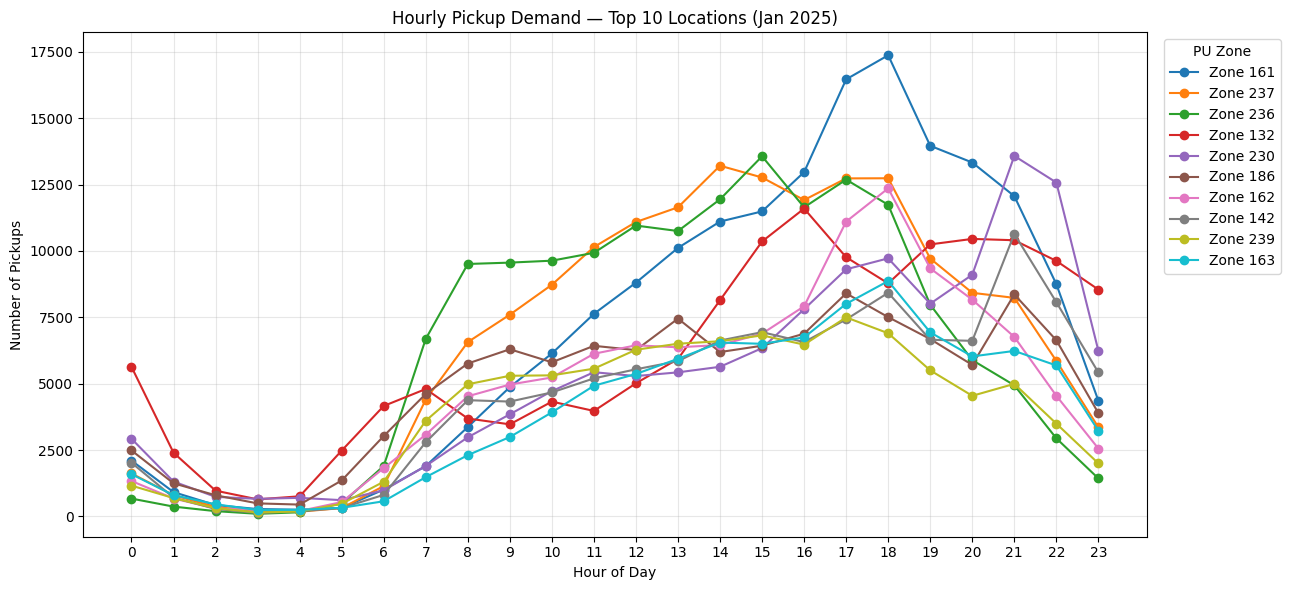

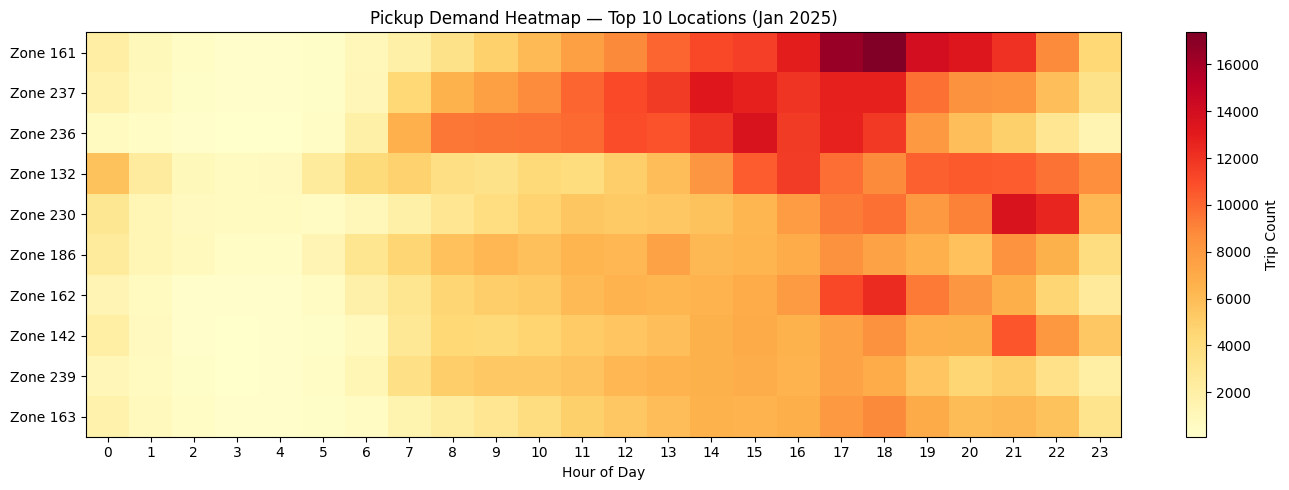

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# extract hour from pickup datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# get top 10 locations by total trip count
top_locations = df['PULocationID'].value_counts().head(10).index.tolist()
df_top = df[df['PULocationID'].isin(top_locations)]

# count trips per hour per location
hourly_demand = (
    df_top.groupby(['PULocationID', 'pickup_hour'])
    .size()
    .reset_index(name='trip_count')
)

# --- Plot 1: Line chart — hourly demand curves per location ---
fig, ax = plt.subplots(figsize=(13, 6))
colors = cm.tab10(np.linspace(0, 1, len(top_locations)))

for color, loc_id in zip(colors, top_locations):
    loc_data = hourly_demand[hourly_demand['PULocationID'] == loc_id].sort_values('pickup_hour')
    ax.plot(loc_data['pickup_hour'], loc_data['trip_count'], marker='o', label=f'Zone {loc_id}', color=color)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Pickups')
ax.set_title('Hourly Pickup Demand — Top 10 Locations (Jan 2025)')
ax.set_xticks(range(24))
ax.legend(title='PU Zone', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Heatmap — hour vs location ---
pivot = hourly_demand.pivot(index='PULocationID', columns='pickup_hour', values='trip_count').fillna(0)
pivot = pivot.loc[top_locations]  # keep top-10 order

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(len(top_locations)))
ax.set_yticklabels([f'Zone {z}' for z in top_locations])
ax.set_xlabel('Hour of Day')
ax.set_title('Pickup Demand Heatmap — Top 10 Locations (Jan 2025)')
plt.colorbar(im, ax=ax, label='Trip Count')
plt.tight_layout()
plt.show()

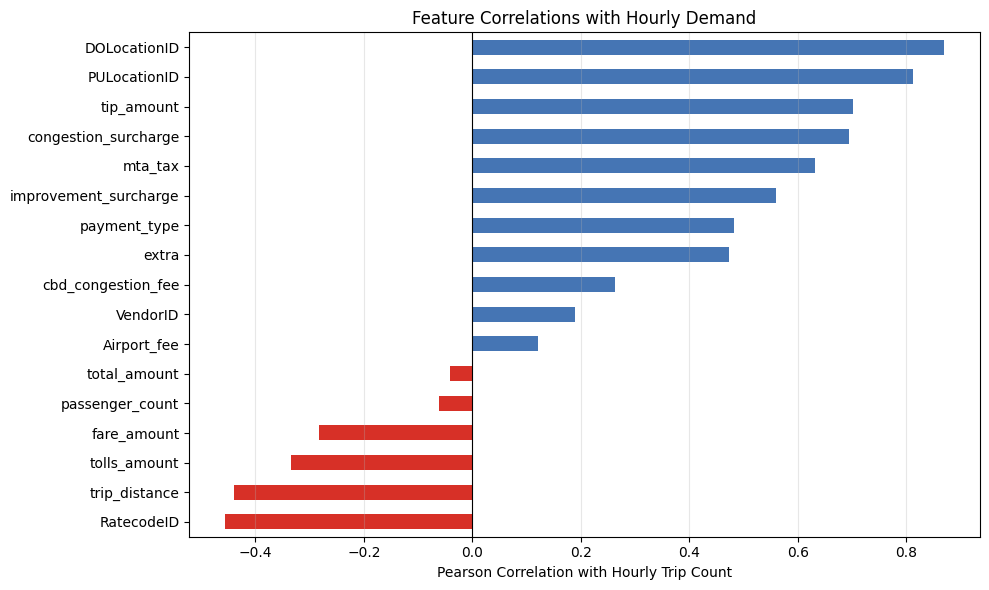

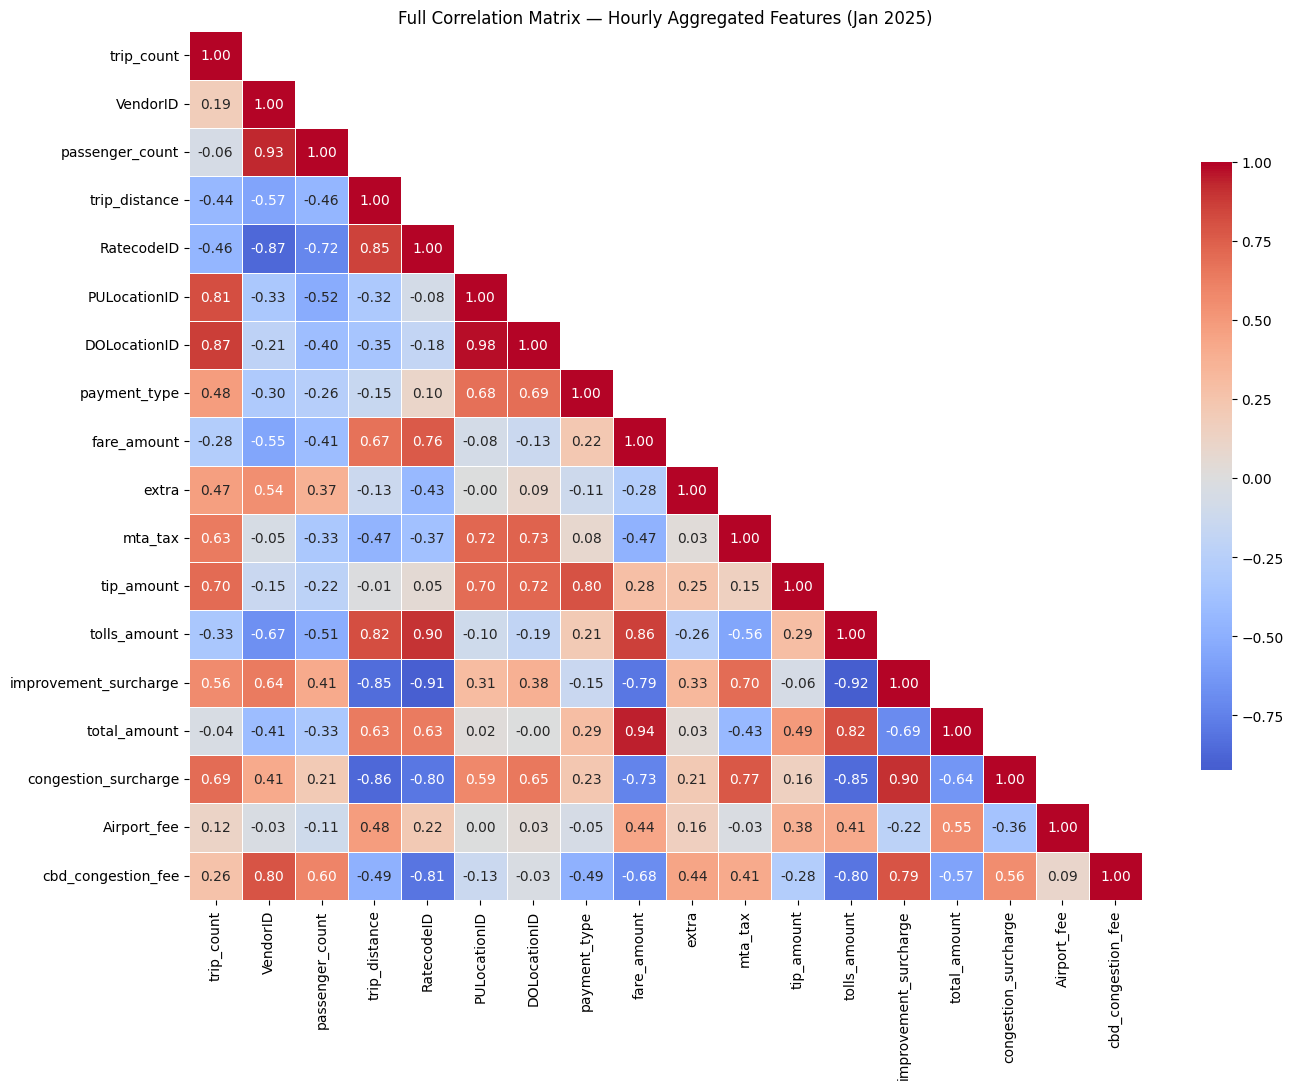

In [14]:
import seaborn as sns

# build hourly aggregate: trip count + mean of every numeric column per hour
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['pickup_hour']]

hourly_agg = df.groupby('pickup_hour').agg(
    trip_count=('PULocationID', 'count'),
    **{col: (col, 'mean') for col in numeric_cols}
).reset_index()

# --- Plot 1: bar chart of correlation with trip_count ---
corr_with_demand = (
    hourly_agg.drop(columns='pickup_hour')
    .corr()['trip_count']
    .drop('trip_count')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_with_demand]
corr_with_demand.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Hourly Trip Count')
ax.set_title('Feature Correlations with Hourly Demand')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: full correlation heatmap across all hourly-aggregated features ---
corr_matrix = hourly_agg.drop(columns='pickup_hour').corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # hide upper triangle (redundant)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.4,
    ax=ax,
    cbar_kws={'shrink': 0.7}
)
ax.set_title('Full Correlation Matrix — Hourly Aggregated Features (Jan 2025)')
plt.tight_layout()
plt.show()